In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
import sklearn
print("numpy :",np.__version__)
print("pandas :",pd.__version__)
print("sklearn :",sklearn.__version__)

numpy : 2.3.5
pandas : 2.3.3
sklearn : 1.7.2


In [3]:
df=pd.read_csv("city_day.csv")

In [4]:
df1=df.copy()

In [5]:
df.shape

(29531, 16)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [7]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [8]:
df.sample(5)

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
5878,Bengaluru,2019-05-04,56.62,116.59,7.60,25.08,26.34,18.79,0.85,3.67,51.98,0.93,2.48,NaN,120.0,Moderate
13686,Gurugram,2019-06-05,97.05,NaN,15.66,36.79,28.04,NaN,0.37,8.60,98.07,0.00,0.00,NaN,208.0,Poor
11178,Delhi,2017-08-07,57.42,NaN,25.72,32.20,5.84,33.07,0.00,NaN,NaN,0.24,0.00,NaN,110.0,Moderate
7768,Chandigarh,2020-04-27,10.30,21.14,2.82,12.76,8.90,27.60,0.53,11.83,23.89,2.89,0.44,1.19,35.0,Good
25680,Patna,2020-05-21,19.31,54.27,56.98,22.42,54.62,3.95,0.42,4.98,39.83,1.18,5.33,1.68,105.0,Moderate


In [9]:
df.replace('?',np.nan,inplace=True)

In [10]:
df.sample(5)

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
13236,Gurugram,2018-03-12,76.06,179.26,17.74,46.30,40.14,NaN,1.15,NaN,85.33,NaN,NaN,NaN,199.0,Moderate
4615,Bengaluru,2015-11-18,19.32,16.42,4.57,15.47,18.77,25.00,1.99,2.75,NaN,NaN,1.15,NaN,126.0,Moderate
3556,Amritsar,2018-06-25,45.02,174.24,10.83,16.07,26.90,6.24,NaN,4.70,43.26,0.88,2.30,3.45,113.0,Moderate
12162,Delhi,2020-04-17,26.93,89.58,8.12,15.83,16.95,26.06,0.64,14.08,53.53,1.07,7.79,0.00,123.0,Moderate
5450,Bengaluru,2018-03-02,30.38,116.47,4.88,38.24,21.33,NaN,0.98,3.53,45.24,0.63,0.98,NaN,87.0,Satisfactory


In [11]:
df=df1.copy()

In [12]:
# Fill AQI_Bucket (categorical)
aqi_bucket = df["AQI_Bucket"].value_counts().idxmax()
df["AQI_Bucket"].fillna(aqi_bucket, inplace=True)

# Fill AQI (numerical)
df["AQI"] = df["AQI"].astype(float)
df["AQI"].fillna(df["AQI"].median(), inplace=True)

In [13]:
(df.isnull().sum() / len(df)) * 100

City           0.000000
Date           0.000000
PM2.5         15.570079
PM10          37.723071
NO            12.129626
NO2           12.139785
NOx           14.171549
NH3           34.973418
CO             6.972334
SO2           13.050692
O3            13.619586
Benzene       19.041008
Toluene       27.229014
Xylene        61.322001
AQI            0.000000
AQI_Bucket     0.000000
dtype: float64

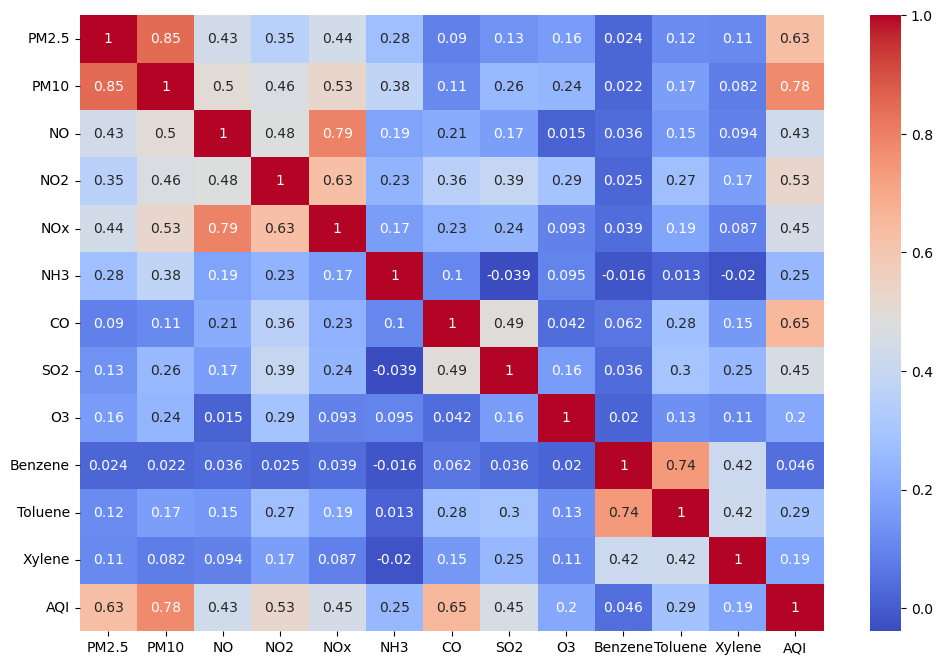

In [14]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [15]:
df[["Xylene","AQI"]].corr()

,Xylene,AQI
Xylene,1.000000,0.190119
AQI,0.190119,1.000000


### Xylene has more than 60% of missing values and since it has positive but weak relation with AQI. Therefore, creating two models with Xylene and without Xylene will help with this decision.

In [16]:
df["Xylene_missing"] = df["Xylene"].isnull().astype(int)
df["Xylene"] = df["Xylene"].fillna(df["Xylene"].median())

### Since AQI is heavily affected by winter smog, summer ozone,monsoon washout, weekday traffic, festivals and crop burning.

In [17]:
df["month"] = pd.to_datetime(df["Date"]).dt.month

city_month_avg = df.groupby(["City", "month"]).mean(numeric_only=True)

city_month_avg.reset_index().to_csv("city_month_lookup.csv", index=False)

### PM2.5 and CO were identified as the strongest AQI drivers,jointly contributing over 80% of the model's predictive importance, indicating particulate and combustion related pollution as the dominant air-quality factors.

In [18]:
# time-based forecasting features

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["City", "Date"])

# lag features
for lag in [1, 3, 7]:
    df[f"AQI_lag_{lag}"] = df.groupby("City")["AQI"].shift(lag)

# rolling features
for window in [3, 7]:
    df[f"AQI_roll_{window}"] = (
        df.groupby("City")["AQI"]
          .rolling(window)
          .mean()
          .reset_index(0, drop=True)
    )

# seasonal intelligence

df["month"] = df["Date"].dt.month
df["winter_flag"] = df["month"].isin([11, 12, 1]).astype(int)
df["monsoon_flag"] = df["month"].isin([6, 7, 8, 9]).astype(int)

# future target = next day AQI

df["AQI_future"] = df.groupby("City")["AQI"].shift(-1)

df = df.dropna()

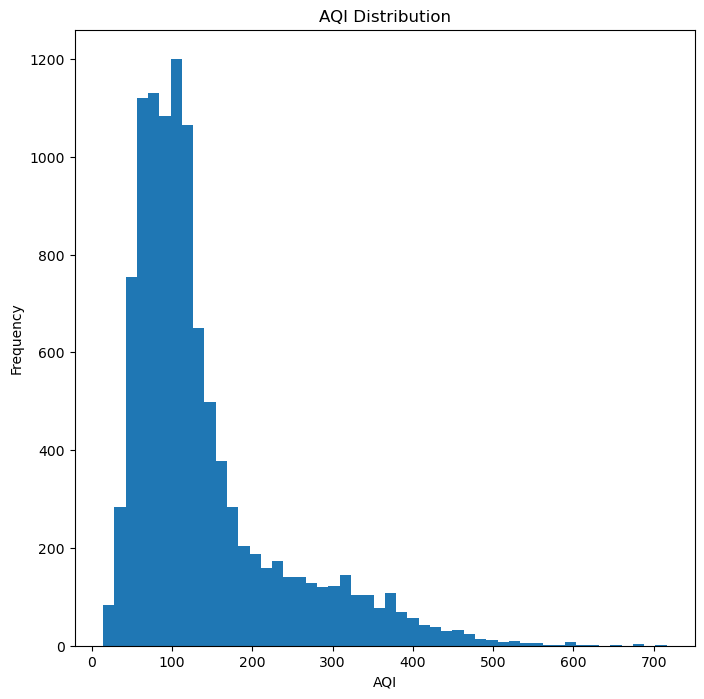

In [19]:
plt.figure(figsize=(8,8))
plt.hist(df["AQI"],bins=50)
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.title("AQI Distribution")
plt.show()

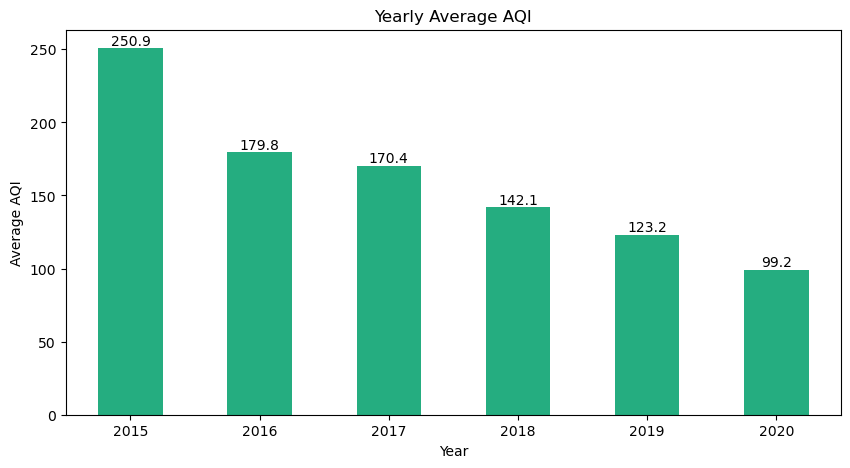

In [20]:
df["Date"] = pd.to_datetime(df["Date"])
df["year"] = df["Date"].dt.year
yearly_aqi = df.groupby("year")["AQI"].mean()
plt.figure(figsize=(10, 5))
ax = yearly_aqi.plot(kind="bar",color="#25AD80")

for i, v in enumerate(yearly_aqi):
    ax.text(i, v + 2, f"{v:.1f}", ha="center")

plt.title("Yearly Average AQI")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.xticks(rotation=0)
plt.savefig("static/yearly_aqi.png", bbox_inches="tight")
plt.show()

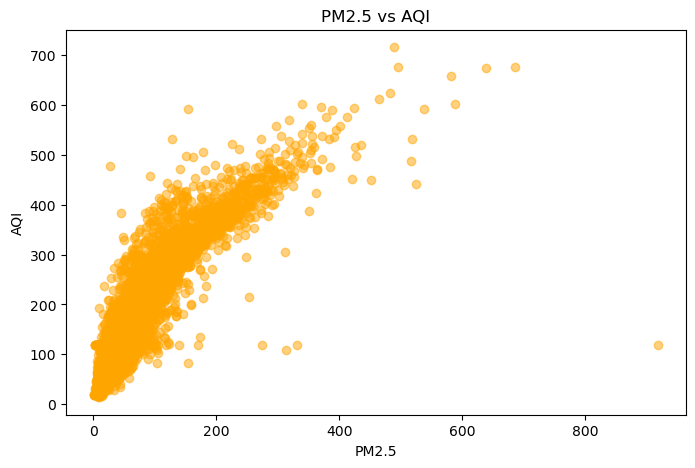

In [21]:
plt.figure(figsize=(8,5))
plt.scatter(df["PM2.5"],df["AQI"],alpha=0.5,color="orange")
plt.xlabel("PM2.5")
plt.ylabel("AQI")
plt.title("PM2.5 vs AQI")
plt.show()

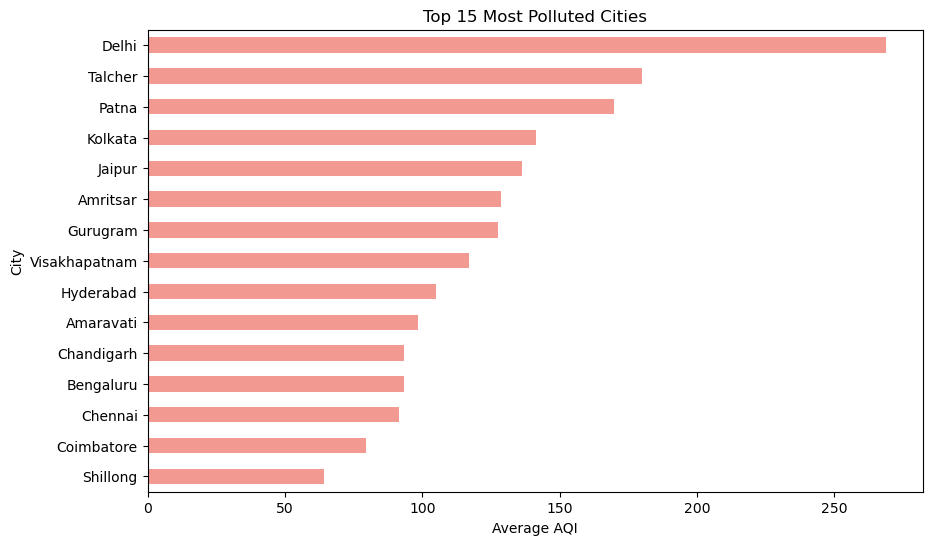

In [22]:
city_avg = df.groupby("City")["AQI"].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(10,6))
city_avg.sort_values().plot(kind="barh",color="#F29991")

plt.title("Top 15 Most Polluted Cities")
plt.xlabel("Average AQI")
plt.ylabel("City")
plt.savefig("static/top15_cities.png",bbox_inches="tight")
plt.show()

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

features = [
    "PM2.5", "PM10", "NO2", "CO", "SO2", "O3",
    "AQI_lag_1", "AQI_lag_3", "AQI_lag_7",
    "AQI_roll_3", "AQI_roll_7",
    "winter_flag", "monsoon_flag"
]

X = df[features]
y = df["AQI_future"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": mean_squared_error(y_test, preds) ** 0.5,
        "R2": r2_score(y_test, preds)
    }

results

{'Linear Regression': {'MAE': 20.61819086356042,
  'RMSE': 30.705906170220302,
  'R2': 0.8933147764266265},
 'Random Forest': {'MAE': 18.60798334875116,
  'RMSE': 29.08631775271074,
  'R2': 0.9042722341546622},
 'XGBoost': {'MAE': 18.633406774078,
  'RMSE': 29.34985773923847,
  'R2': 0.9025296701500656}}

In [24]:
performance_df = pd.DataFrame(results).T
performance_df.sort_values("RMSE")

,MAE,RMSE,R2
Random Forest,18.607983,29.086318,0.904272
XGBoost,18.633407,29.349858,0.902530
Linear Regression,20.618191,30.705906,0.893315


In [25]:
best_model = models["Random Forest"]
preds = best_model.predict(X_test)

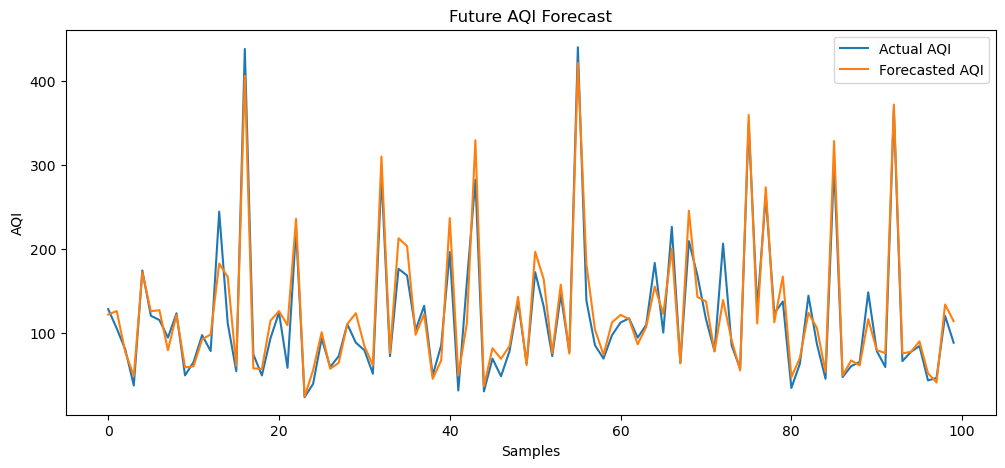

In [26]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values[:100], label="Actual AQI")
plt.plot(preds[:100], label="Forecasted AQI")
plt.title("Future AQI Forecast")
plt.xlabel("Samples")
plt.ylabel("AQI")
plt.legend()
plt.show()

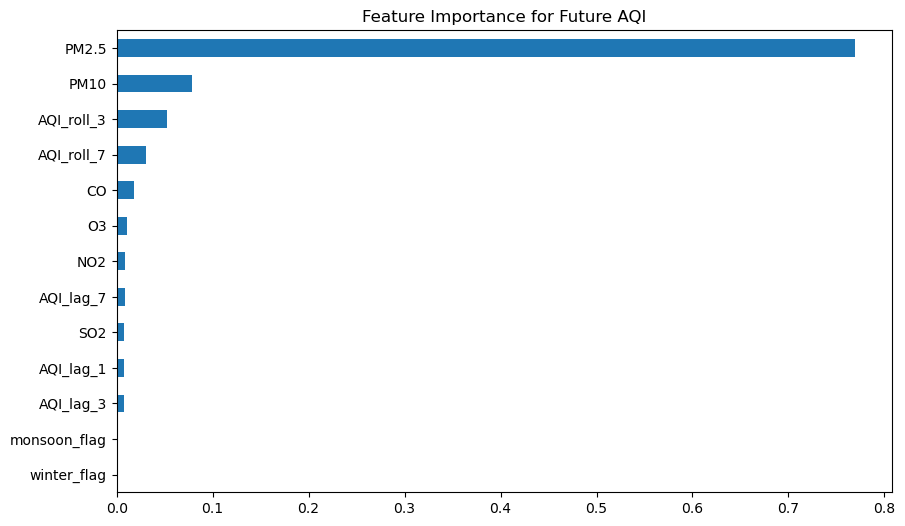

In [27]:
importance = pd.Series(best_model.feature_importances_, index=features)
importance.sort_values().plot(kind="barh", figsize=(10, 6))
plt.title("Feature Importance for Future AQI")
plt.show()

In [30]:
from sklearn.model_selection import GridSearchCV, cross_val_score
rf = RandomForestRegressor(random_state=42)
param_grid = {
    "n_estimators": [100, 300],
    "max_depth": [10, 20],
    "max_features": ["sqrt"],
    "min_samples_split": [2, 5]
}
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=1,
    verbose=1
)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
print("Best Parameters:", grid_rf.best_params_)
print("Best CV R2:", grid_rf.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
Best CV R2: 0.89605067429076


In [31]:
cv_scores = cross_val_score(best_rf, X, y, cv=5, scoring="r2")

print("Cross Validation R2 Scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

Cross Validation R2 Scores: [0.75118436 0.90182105 0.87971317 0.88478739 0.84519778]
Mean CV R2: 0.8525407511716778
Std Dev: 0.05391432278873281


In [32]:
y_pred = best_rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("Final Test R2:", r2)
print("Final RMSE:", rmse)
print("Final MAE:", mae)

Final Test R2: 0.906733875525426
Final RMSE: 28.709904509284506
Final MAE: 18.683831524512897


In [33]:
def health_advice(aqi):
    if aqi <= 50:
        return "Good - Safe for outdoor activity"
    elif aqi <= 100:
        return "Moderate - Sensitive people be careful"
    elif aqi <= 200:
        return "Poor - Wear a mask outdoors"
    elif aqi <= 300:
        return "Very Poor - Avoid outdoor exercise"
    return "Severe - Stay indoors"

In [34]:
sample_aqi = int(preds[0])
print("Predicted AQI:", sample_aqi)
print("Advice:", health_advice(sample_aqi))

Predicted AQI: 121
Advice: Poor - Wear a mask outdoors


In [35]:
df["AQI_spike"] = (df["AQI"].diff().abs() > 80).astype(int)

spikes = df[df["AQI_spike"] == 1][["City", "Date", "AQI"]]
spikes.head()

,City,Date,AQI
2129,Amaravati,2017-12-01,191.0
2137,Amaravati,2017-12-09,196.0
2267,Amaravati,2018-04-18,118.0
2492,Amaravati,2018-11-29,118.0
2499,Amaravati,2018-12-06,118.0


In [36]:
# persona-based advisory system
def persona_advice(aqi, persona):
    if persona == "asthma":
        if aqi > 100:
            return "High risk for asthma patients. Avoid going outside and use inhaler support if prescribed."
        return "Low risk, but avoid peak traffic hours."
    elif persona == "child":
        if aqi > 150:
            return "Children should avoid outdoor sports and school playground activities."
        return "Short outdoor activity is safe."

    elif persona == "senior":
        if aqi > 100:
            return "Senior citizens should stay indoors and avoid long walks."
        return "Safe for light outdoor movement."

    else:
        if aqi > 200:
            return "Wear a mask and reduce outdoor exposure."
        return "Normal activity allowed."

In [37]:
sample_aqi = int(preds[0])

print("=== Hospital Respiratory Alert ===")
print("Predicted AQI:", sample_aqi)
print("Asthma Advisory:", persona_advice(sample_aqi, "asthma"))

if sample_aqi > 200:
    print("Hospital Alert: High asthma emergency risk - increase pulmonology readiness")
elif sample_aqi > 100:
    print("Hospital Alert: Prepare for increased respiratory OPD cases")
else:
    print("Hospital Alert: Normal respiratory patient load expected")

=== Hospital Respiratory Alert ===
Predicted AQI: 121
Asthma Advisory: High risk for asthma patients. Avoid going outside and use inhaler support if prescribed.
Hospital Alert: Prepare for increased respiratory OPD cases


In [38]:
sample_aqi = int(preds[0])

print("Predicted AQI:", sample_aqi)
print("\n=== Primary Hospital Use Case ===")
print("Asthma Patient:", persona_advice(sample_aqi, "asthma"))
print("\n=== Extended Vulnerable Groups ===")
print("Child:", persona_advice(sample_aqi, "child"))
print("Senior:", persona_advice(sample_aqi, "senior"))
print("Adult:", persona_advice(sample_aqi, "adult"))

Predicted AQI: 121

=== Primary Hospital Use Case ===
Asthma Patient: High risk for asthma patients. Avoid going outside and use inhaler support if prescribed.

=== Extended Vulnerable Groups ===
Child: Short outdoor activity is safe.
Senior: Senior citizens should stay indoors and avoid long walks.
Adult: Normal activity allowed.


In [39]:
if sample_aqi > 200:
    print("\nHospital Alert: High asthma emergency risk - increase pulmonology readiness")
elif sample_aqi > 100:
    print("\nHospital Alert: Prepare for increased respiratory OPD cases")
else:
    print("\nHospital Alert: Normal respiratory patient load expected")


Hospital Alert: Prepare for increased respiratory OPD cases


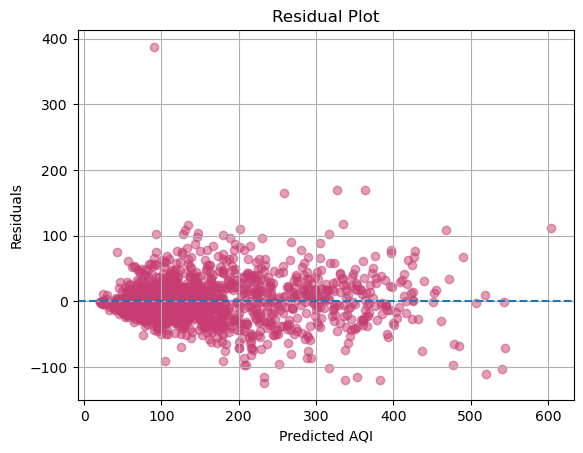

In [40]:
residuals=y_test-y_pred
plt.scatter(y_pred, residuals, alpha=0.5,color="#C73D72")
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted AQI")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

In [41]:
from geopy.geocoders import Nominatim
import time
geolocator=Nominatim(user_agent="aqi_map")
cities=df["City"].dropna().unique()
city_coords={}
for city in cities:
    try:
        location=geolocator.geocode(f"{city}, India")
        if location:
            city_coords[city]=[location.latitude, location.longitude]
        time.sleep(1)
    except:
        city_coords[city]=None
print(city_coords)

{'Aizawl': [23.7277631, 92.7179947], 'Amaravati': [16.494222, 80.5105858], 'Amritsar': [31.6356659, 74.8787496], 'Bengaluru': [12.9767936, 77.590082], 'Chandigarh': [30.7334421, 76.7797143], 'Chennai': [13.0836939, 80.270186], 'Coimbatore': [11.0018115, 76.9628425], 'Delhi': [28.6138954, 77.2090057], 'Gurugram': [28.4646148, 77.0299194], 'Hyderabad': [17.360589, 78.4740613], 'Jaipur': [26.9154576, 75.8189817], 'Kolkata': [22.5726459, 88.3638953], 'Patna': [25.6093239, 85.1235252], 'Shillong': [25.5759931, 91.8827872], 'Talcher': [20.9322302, 85.2005822], 'Visakhapatnam': [17.6935526, 83.2921297]}


In [42]:
rows=[]
for city , coord in city_coords.items():
    if coord:
        rows.append({
            "City": city,
            "Latitude": coord[0],
            "Longitude": coord[1]
        })
coords_df=pd.DataFrame(rows)
coords_df.to_csv("city_coordinates.csv", index=False)

In [43]:
import sys
!"{sys.executable}" -m pip install folium

In [44]:
import folium

m = folium.Map(location=[22.5, 78.9], zoom_start=4)

city_avg = df.groupby("City")["AQI"].mean()

def get_color(aqi):
    if aqi <= 50:
        return "green"
    elif aqi <= 100:
        return "yellow"
    elif aqi <= 200:
        return "orange"
    elif aqi <= 300:
        return "red"
    else:
        return "purple"

for _, row in coords_df.iterrows():
    city = row["City"]
    lat = row["Latitude"]
    lon = row["Longitude"]

    if city in city_avg.index:
        aqi = city_avg[city]

        folium.CircleMarker(
            location=[lat, lon],
            radius=6,
            popup=f"{city}: AQI {aqi:.1f}",
            color=get_color(aqi),
            fill=True,
            fill_color=get_color(aqi),
            fill_opacity=0.8
        ).add_to(m)

m

### <b> Green: </b> Cleaner cities
### <b> Yellow: </b> Moderate AQI cities
### <b> Orange: </b> Polluted cities
###  <b> Red: </b> Very Polluted cities
### <b> Purple: </b> Severe Hotspots

In [45]:
import pickle
with open('final_model.pkl','wb') as file:
    pickle.dump(best_rf, file)

In [46]:
m.save("templates/aqi_map.html")

In [ ]:
city_month_lookup = (df.groupby(["City", "month"]).mean(numeric_only=True).reset_index())

city_month_lookup.to_csv("city_month_lookup.csv", index=False)
print("CSV saved successfully!")